In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [32]:
df = pd.read_csv("zameen_lahore_dataset.csv")
print(df.head())
print(df.info())


                                      Location  Beds  Baths  \
0                     DHA Phase 1, DHA Defence   5.0    6.0   
1                    Lake City Meadows, Lahore   3.0    4.0   
2                                          NaN   NaN    NaN   
3                               FCC, Gulberg 4   4.0    5.0   
4  Eden Boulevard Housing Scheme, College Road   4.0    5.0   

                                               Title          Added_Date  \
0  2 KANAL OWNER BUILD SPANISH BUNGALOW FOR SALE ...   Added: 1 hour ago   
1                    Brand New Modern House With Gas  Added: 3 hours ago   
2                                                NaN                 NaN   
3  Syed Maratab Ali Road 1 Kanal Double Storey House  Added: 6 hours ago   
4  4.5 MARLA FACING PARK DOUBLE STORY HOUSE FOR S...  Added: 8 hours ago   

   Price_thnds  Area_sqft  
0  160000000.0   10890.00  
1   22500000.0    1361.25  
2   28800000.0        NaN  
3  140000000.0    5445.00  
4   16500000.0    1089.0

In [33]:
df=df[['Location','Beds','Baths','Area_sqft','Price_thnds']]

In [34]:
df = df.dropna()

In [35]:
df = df[df['Price_thnds'] < 200000000]

In [36]:
df = pd.get_dummies(df, columns=['Location'], drop_first=True)

In [39]:
X = df.drop("Price_thnds", axis=1)
y = df["Price_thnds"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [41]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [42]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [44]:
predictions = model.predict(X_test)

In [45]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)

Mean Absolute Error: 12619421.667711662
Root Mean Squared Error: 19085685.148416072


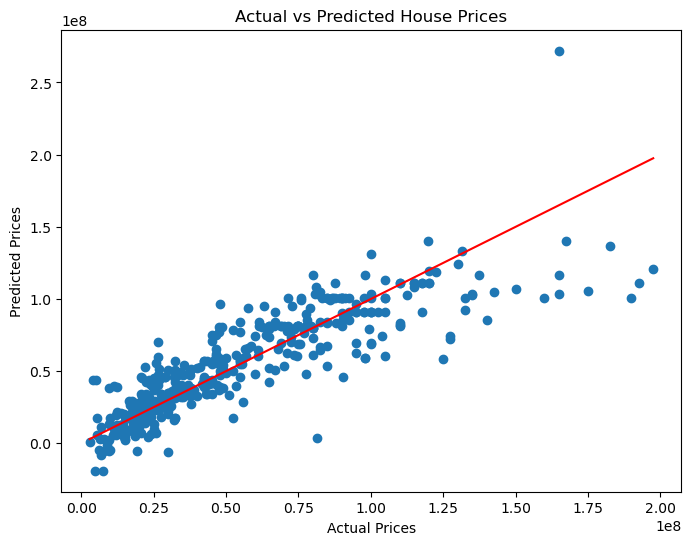

In [46]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")

plt.show()

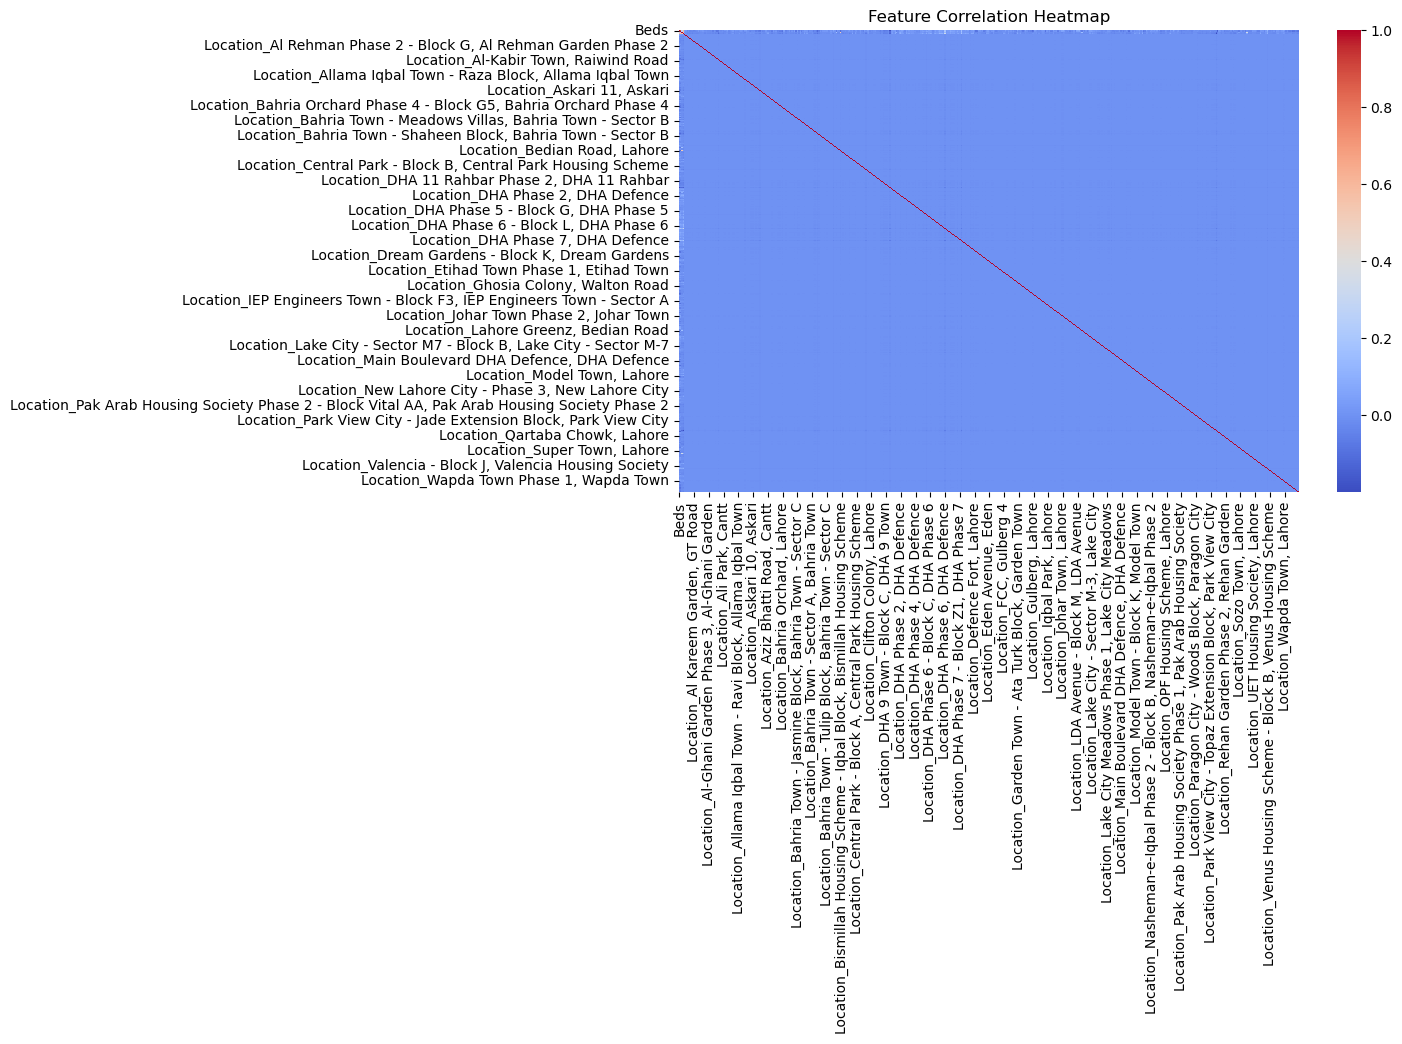

In [47]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()